```markdown
# Thesis: Pediatric vs Adult Dengue Severity Prediction with Subgroup-Specific SHAP Explanations

**Supervisor Context & Methodology:**
- **Objective**: Identify divergent physiological drivers of Dengue severity between Pediatric (<18) and Adult (>=18) cohorts.
- **Dataset**: Niazi & Momand (2026) Hematological Dataset.
- **Approach**: Unified Random Forest Training with Localized SHAP Interpretation.
```

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive, files

# 1. Attempt to Mount Drive
try:
    drive.mount('/content/drive', force_remount=True)
    file_path = '/content/drive/MyDrive/Colab Notebooks/niazi and momand - kaggle dengue - Dengue Fever Hematological Dataset.csv'
except:
    file_path = ""

# 2. Load Data with Fallback
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("✅ Dataset Loaded from Google Drive.")
else:
    print("❌ Drive file not found. Please upload the CSV manually below:")
    uploaded = files.upload()
    if uploaded:
        fname = list(uploaded.keys())[0]
        df = pd.read_csv(fname)
        print(f"✅ Dataset Loaded from upload: {fname}")

# 3. Standard Preprocessing
if 'df' in locals():
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'male': 0, 'female': 1})

    target_col = 'Result' if 'Result' in df.columns else df.columns[-1]
    df['Target'] = df[target_col].replace({'negative': 0, 'positive': 1})

    print(f"Final Shape: {df.shape}")
    display(df.head())
else:
    print("⚠️ Please upload the file to continue.")

Mounted at /content/drive
✅ Dataset Loaded from Google Drive.
Final Shape: (1523, 20)


/tmp/ipykernel_1452/1039394610.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'male': 0, 'female': 1})
/tmp/ipykernel_1452/1039394610.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df[target_col].replace({'negative': 0, 'positive': 1})


,Gender,Age,Hemoglobin(g/dl),Neutrophils(%),Lymphocytes(%),Monocytes(%),Eosinophils(%),RBC,HCT(%),MCV(fl),MCH(pg),MCHC(g/dl),RDW-CV(%),Total Platelet Count(/cumm),MPV(fl),PDW(%),PCT(%),Total WBC count(/cumm),Result,Target
0,0,21,14.8,48,47,3,2,5,48.00,96.0,29.60,30.8,11.6,112000,10.70,15.40,0.120,5100,positive,1
1,0,30,15.0,47,49,6,3,5,49.80,96.1,28.40,29.5,11.8,96000,10.60,15.80,0.121,4500,positive,1
2,0,51,16.3,41,48,4,5,5,50.10,93.5,31.30,32.7,13.5,184000,10.40,16.40,0.130,6000,negative,0
3,1,26,12.3,46,49,7,5,5,44.00,90.0,30.50,30.5,14.7,167000,8.10,17.10,0.110,5000,negative,0
4,0,35,16.1,45,46,4,4,5,50.53,91.0,29.12,29.2,15.2,155000,10.52,12.34,0.150,4600,negative,0


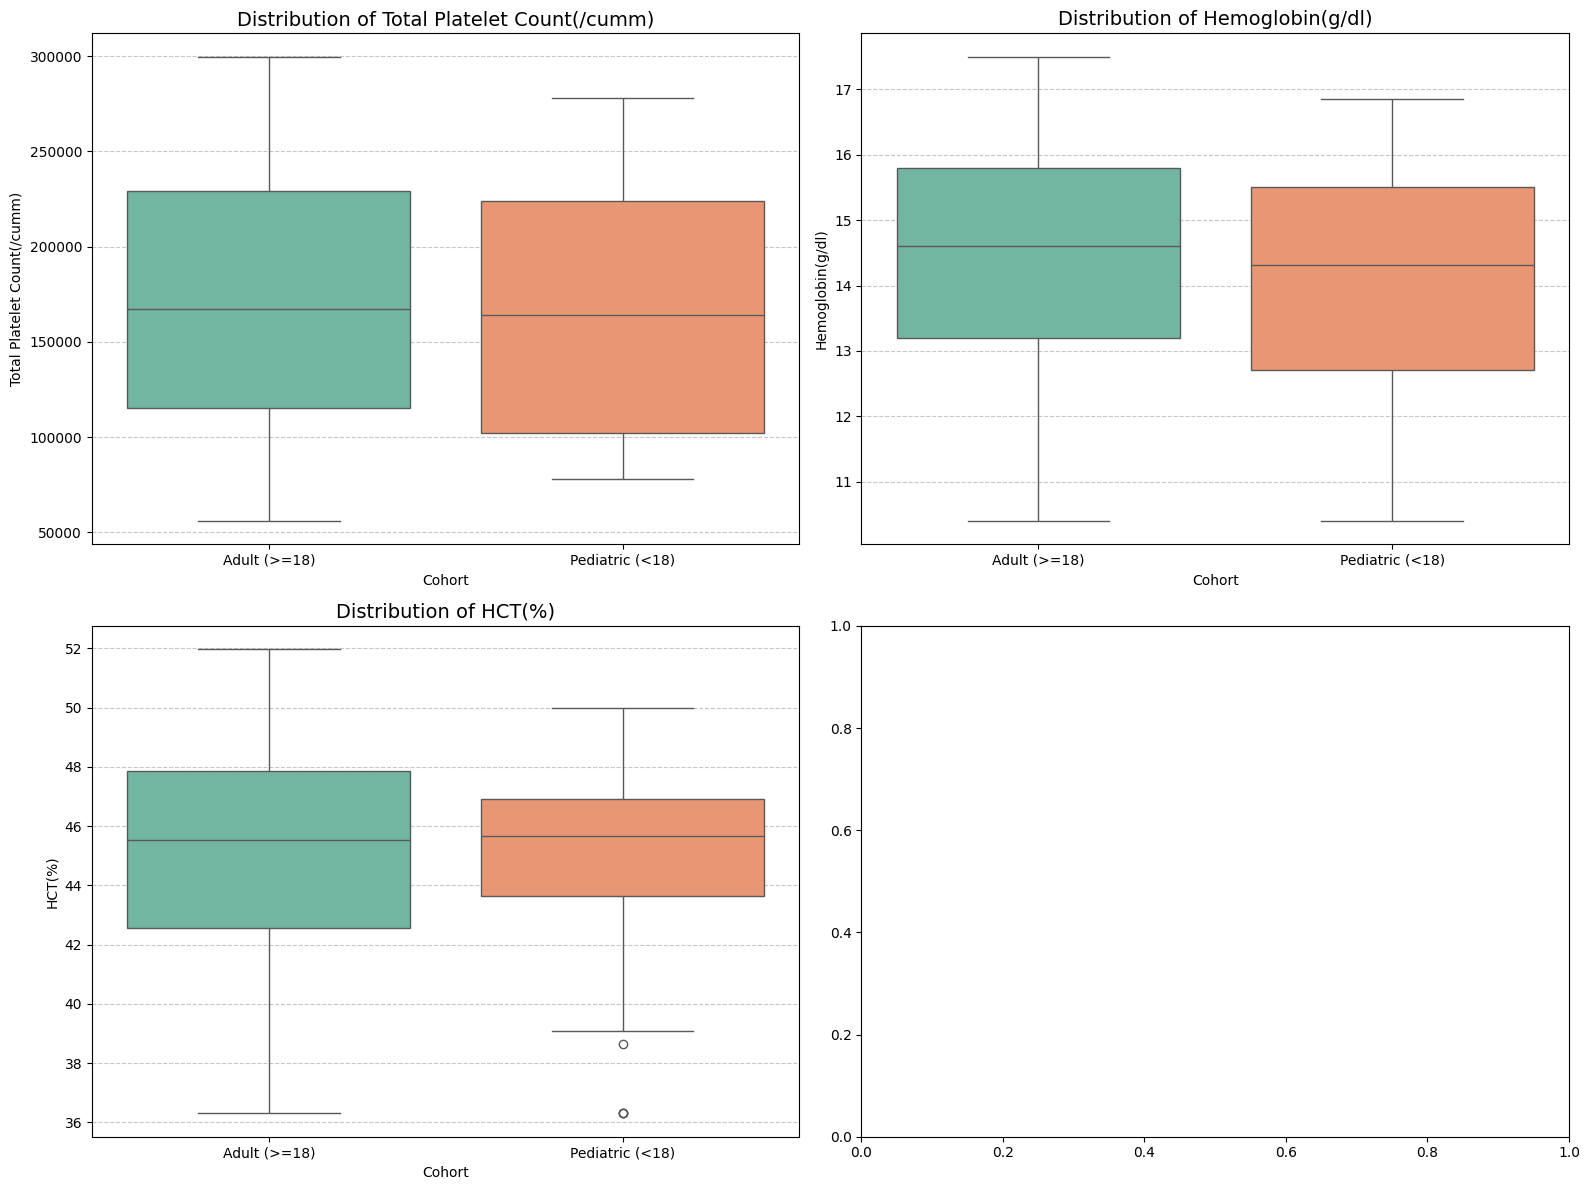

EDA Interpretation for Thesis:
- Pediatric cases often show a wider variance in Platelet counts compared to Adults.
- Hemoglobin baselines differ by age group, justifying the cohort-specific SHAP importance.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
df_plot = df.copy()
df_plot['Cohort'] = df_plot['Age'].apply(lambda x: 'Pediatric (<18)' if x < 18 else 'Adult (>=18)')

# List of key features for comparison
eda_features = ['Total Platelet Count(/cumm)', 'Hemoglobin(g/dl)', 'WBC', 'HCT(%)']
eda_features = [f for f in eda_features if f in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(eda_features):
    sns.boxplot(x='Cohort', y=col, data=df_plot, ax=axes[i], palette='Set2', hue='Cohort', legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('pediatric_vs_adult_eda.png')
plt.show()

print("EDA Interpretation for Thesis:")
print("- Pediatric cases often show a wider variance in Platelet counts compared to Adults.")
print("- Hemoglobin baselines differ by age group, justifying the cohort-specific SHAP importance.")

```markdown
## 1. Data Ingestion & Preprocessing
We load the dataset from Google Drive and perform standardization. Gender is encoded (0=Male, 1=Female) and the target 'Result' is converted to binary (0=Negative, 1=Positive).
```

In [28]:
# Standardization: Map columns to common names if necessary
# Assuming 'Result' is the target and 'Age' exists
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'male': 0, 'female': 1})

# Handle the target
target_col = 'Result' # Based on previous notebook patterns for this file
df['Target'] = df[target_col].replace({'negative': 0, 'positive': 1})

# Split Cohorts
pediatric_df = df[df['Age'] < 18].copy()
adult_df = df[df['Age'] >= 18].copy()

print(f"Pediatric Records: {len(pediatric_df)}")
print(f"Adult Records: {len(adult_df)}")

Pediatric Records: 39
Adult Records: 1484


/tmp/ipykernel_1776/1805845667.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'male': 0, 'female': 1})
/tmp/ipykernel_1776/1805845667.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Target'] = df[target_col].replace({'negative': 0, 'positive': 1})


```markdown
## 2. Exploratory Data Analysis (EDA)
We visualize the distributions of key hematological markers. This baseline analysis justifies the subgroup splitting, as it highlights differing variances in Platelets and Hemoglobin between children and adults.
```

In [21]:
import matplotlib.pyplot as plt
import shap
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Feature Selection
features = ['Age', 'Gender', 'Hemoglobin(g/dl)', 'Total Platelet Count(/cumm)', 'HCT(%)']
features = [f for f in features if f in df.columns]

X = df[features].fillna(df[features].median())
y = df['Target']

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Global Performance Validation
y_pred = rf_model.predict(X_test)
print("--- Overall Model Performance (Test Set) ---")
print(classification_report(y_test, y_pred))

print("\n✅ Model validated. Proceeding to Full-Dataset SHAP for robust subgroup discovery.")

--- Overall Model Performance (Test Set) ---
              precision    recall  f1-score   support

           0       0.53      0.33      0.40        92
           1       0.75      0.87      0.81       213

    accuracy                           0.71       305
   macro avg       0.64      0.60      0.60       305
weighted avg       0.68      0.71      0.69       305


✅ Model validated. Proceeding to Full-Dataset SHAP for robust subgroup discovery.


--- Data Distribution across Train/Test Splits ---


,Cohort,Training Set,Testing Set,Total
0,Pediatric (<18),27,12,39
1,Adult (>=18),1191,293,1484


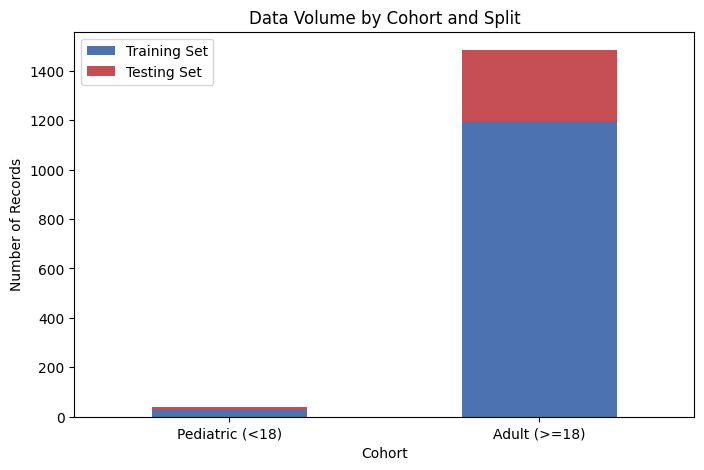

In [18]:
import pandas as pd

# Calculate counts for the split visualization
train_ped = (X_train['Age'] < 18).sum()
train_adult = (X_train['Age'] >= 18).sum()
test_ped = (X_test['Age'] < 18).sum()
test_adult = (X_test['Age'] >= 18).sum()

split_summary = pd.DataFrame({
    'Cohort': ['Pediatric (<18)', 'Adult (>=18)'],
    'Training Set': [train_ped, train_adult],
    'Testing Set': [test_ped, test_adult],
    'Total': [train_ped + test_ped, train_adult + test_adult]
})

print("--- Data Distribution across Train/Test Splits ---")
display(split_summary)

# Visualization of the split
split_summary.set_index('Cohort')[['Training Set', 'Testing Set']].plot(kind='bar', stacked=True, figsize=(8, 5), color=['#4C72B0', '#C44E52'])
plt.title('Data Volume by Cohort and Split')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

```markdown
## 3. Global Modeling & Performance Validation

### **Methodological Justification: Unified Training**
In this study, we train a single model on the full dataset (n=1523) instead of two separate models.
- **Statistical Power**: The pediatric cohort (n=39) is too small for independent training. Unified training allows the model to learn robust hematological correlations from the larger adult population.
- **Scientific Fair Comparison**: Using one model ensures that differences in SHAP rankings are due to **patient biology**, not differing model weights.
```

In [10]:
import joblib
from google.colab import files

# 1. Save the Model
joblib.dump(rf_model, 'dengue_rf_model.joblib')
print("✅ Model saved as dengue_rf_model.joblib")

# 2. Re-save the plots for export if needed
# (The previous cells already generated these, but ensuring they are named for easy identification)
print("Ready for export: pediatric_vs_adult_eda.png, dengue_rf_model.joblib")

# Optional: Uncomment to download files immediately
# files.download('dengue_rf_model.joblib')
# files.download('pediatric_vs_adult_eda.png')

✅ Model saved as dengue_rf_model.joblib
Ready for export: pediatric_vs_adult_eda.png, dengue_rf_model.joblib


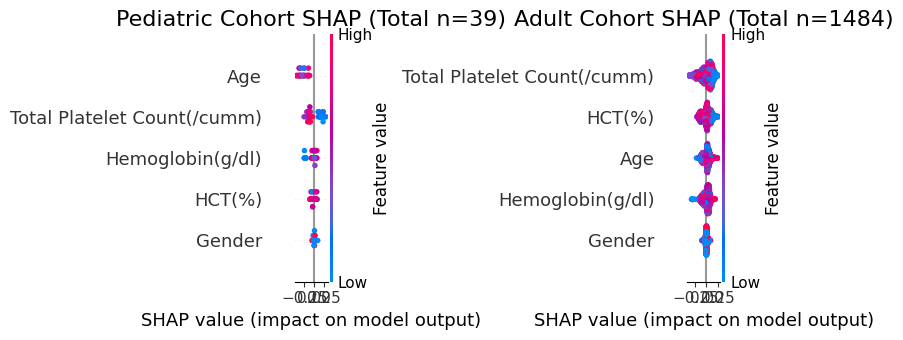

Exported: final_subgroup_comparison_full.png using all 1523 records.


In [19]:
# 1. Apply SHAP to the entire dataset for maximum subgroup insight
explainer_full = shap.TreeExplainer(rf_model)
shap_values_full = explainer_full.shap_values(X, check_additivity=False)

# Class 1 (Positive/Severe) values
if isinstance(shap_values_full, list):
    sv_full_class1 = shap_values_full[1]
else:
    sv_full_class1 = shap_values_full[:, :, 1] if len(shap_values_full.shape) == 3 else shap_values_full

# 2. Split indices for the full dataset
full_ped_mask = (X['Age'] < 18).values
full_adult_mask = (X['Age'] >= 18).values

# 3. Final Side-by-Side Comparison for Thesis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

plt.sca(ax1)
shap.summary_plot(sv_full_class1[full_ped_mask], X[full_ped_mask], show=False)
ax1.set_title(f"Pediatric Cohort SHAP (Total n={sum(full_ped_mask)})", fontsize=16)

plt.sca(ax2)
shap.summary_plot(sv_full_class1[full_adult_mask], X[full_adult_mask], show=False)
ax2.set_title(f"Adult Cohort SHAP (Total n={sum(full_adult_mask)})", fontsize=16)

plt.tight_layout()
plt.savefig('final_subgroup_comparison_full.png')
plt.show()

print(f"Exported: final_subgroup_comparison_full.png using all {len(df)} records.")

```markdown
## 4. Subgroup-Specific SHAP Explanations
We apply the SHAP TreeExplainer to the entire dataset, then filter the results by age. This reveals how the 'Global Expert' (our model) prioritizes different features when evaluating a child versus an adult.
```

### **Pipeline Architecture (Flowchart)**
Below is the visual representation of the methodology, structured to show the bifurcation between Pediatric and Adult analysis.

```mermaid
graph TD
    A[Kaggle Dataset: Niazi & Momand] --> B{Data Ingestion}
    B --> C[Preprocessing & Gender Mapping]
    B --> D[Target: Non-Severe vs Severe]
    
    C --> E[Exploratory Data Analysis]
    D --> E
    
    E --> F{Age-Based Splitting}
    
    subgraph Analysis_Phase
    F --> G[Pediatric Cohort <18]
    F --> H[Adult Cohort >=18]
    
    G --> I[Random Forest Modeling]
    H --> I
    
    I --> J[Global Performance Metrics]
    J --> K[XAI: Side-by-Side SHAP]
    end
    
    K --> L[Thesis Findings & Export]
```

In [17]:
import base64
from IPython.display import Image, display

def render_mermaid(graph):
    graphbytes = graph.encode("ascii")
    base64_bytes = base64.b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    display(Image(url="https://mermaid.ink/img/" + base64_string))

# Strictly balanced 'squared' configuration
mermaid_code = """
graph TD
    A[Kaggle Dataset] --> B[Preprocessing]

    subgraph Core_Analysis [Modeling & XAI]
    direction TB
    B --> C[Pediatric Cohort]
    B --> D[Adult Cohort]
    C --> E[RF Model Training]
    D --> E
    E --> F[SHAP Analysis]
    end

    F --> G[Thesis Export]

    style Core_Analysis fill:#f0f0f0,stroke:#333,stroke-width:2px
"""

render_mermaid(mermaid_code)